# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who:
U.S. road users impacted by fatal crashes (drivers, passengers, pedestrians, pedalcyclists), and decision-makers like transportation agencies who use these trends to target safety policies.

What:
How total traffic fatalities have changed over time, and which road-user groups contribute most to those fatalities (and how that mix changes over time).

How:
Use a line chart to show total fatalities by year, then mabye a grouped bar chart (or stacked bar) to compare road-user categories in the most recent year (or two years) to highlight which groups are most affected.

# 3. Homework - work with your own data

In [6]:
!pip install xlrd


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [3]:
import os
os.listdir()

['NHTSA.xls',
 'Cole Nussbaumer Knaflic - Storytelling with Data_ A Data Visualization Guide for Business Professionals (2016_2015, John Wiley & Sons) - libgen.li.pdf',
 'bank_customers.csv',
 'OMDS-ModB2-Week1-Nijjer-Paramdeep.ipynb',
 'Module B 02 Team Contract.docx',
 'OMDS-ModB2-Week2-Nijjer-Paramdeep.ipynb',
 '.ipynb_checkpoints',
 'OMDS-ModB2-Week4-Nijjer-Paramdeep.ipynb',
 'OMDS-ModB2-Week3-Nijjer-Paramdeep.ipynb']

In [4]:
file_path = "NHTSA.xls"

df_raw = pd.read_csv(
    file_path,
    sep="\t",
    na_values=["-", "—", ""],   
    dtype=str                  
)

df_raw.head()

,colname,2023,2022,2021,2020,2019,2018,2017,2016,2015,...,2001,2000,1999,1998,1997,1996,1995,1994,isHeader,Unnamed: 32
0,Motor Vehicle Traffic Crashes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
1,Fatal Crashes,37654,39422,39785,35935,33487,33919,34560,34748,32538,...,37862,37526,37140,37107,37324,37494,37241,36254,0,NaN
2,Traffic Crash Fatalities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,Vehicle Occupants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Drivers,19553,20964,21716,19552,17984,18321,18819,18717,17615,...,22914,22914,22971,22654,22730,22572,22370,21596,0,NaN


In [5]:
df = df_raw.copy()

# year columns are like 2023, 2022, ...
year_cols = [c for c in df.columns if c.isdigit()]

for c in year_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 33 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   colname      25 non-null     object 
 1   2023         19 non-null     float64
 2   2022         19 non-null     float64
 3   2021         19 non-null     float64
 4   2020         19 non-null     float64
 5   2019         19 non-null     float64
 6   2018         19 non-null     float64
 7   2017         19 non-null     float64
 8   2016         19 non-null     float64
 9   2015         19 non-null     float64
 10  2014         19 non-null     float64
 11  2013         19 non-null     float64
 12  2012         19 non-null     float64
 13  2011         19 non-null     float64
 14  2010         19 non-null     float64
 15  2009         19 non-null     float64
 16  2008         19 non-null     float64
 17  2007         19 non-null     float64
 18  2006         19 non-null     float64
 19  2005      

In [6]:
df.describe()


,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,...,2003,2002,2001,2000,1999,1998,1997,1996,1995,1994
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,...,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,54505.266316,54528.443158,54398.698421,53005.648947,52490.695263,52321.000000,51884.696842,51519.161579,50380.373158,49159.766842,...,46487.826842,46055.874737,45346.392105,44899.143684,43952.776316,43430.965263,43048.472105,42656.254737,42076.133684,41406.775263
std,108018.098468,107112.978275,106592.359913,105646.729077,105650.477258,104994.037596,103650.263699,102702.671313,101294.882852,99908.997978,...,88175.719524,87070.990413,85858.885323,84899.612742,82618.375068,81498.447710,80388.069319,79468.058508,78310.717807,77340.013755
min,1.260000,1.340000,1.380000,1.340000,1.110000,1.140000,1.170000,1.190000,1.150000,1.080000,...,1.480000,1.510000,1.510000,1.530000,1.550000,1.580000,1.650000,1.690000,1.730000,1.730000
25%,184.500000,187.500000,172.500000,155.500000,175.000000,134.500000,155.000000,167.000000,152.000000,137.500000,...,122.000000,112.000000,112.500000,113.500000,122.500000,119.000000,133.500000,128.000000,113.500000,107.500000
50%,6335.000000,6421.000000,6579.000000,6011.000000,5846.000000,5962.000000,6075.000000,6080.000000,5494.000000,4910.000000,...,4774.000000,4851.000000,4901.000000,4763.000000,4939.000000,5228.000000,5321.000000,5449.000000,5584.000000,5489.000000
75%,31700.000000,33425.000000,34061.500000,30776.000000,28689.000000,29125.500000,29845.000000,30012.000000,28218.500000,26181.500000,...,36052.000000,36298.000000,35552.500000,35488.500000,35266.000000,35097.500000,35466.500000,35514.000000,35152.500000,34126.000000
max,334915.000000,333271.000000,332049.000000,331527.000000,328330.000000,326838.000000,325122.000000,323072.000000,320739.000000,318386.000000,...,290108.000000,287625.000000,284969.000000,282162.000000,272691.000000,270248.000000,267784.000000,265229.000000,262803.000000,260327.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum().sort_values(ascending=False).head(10)


Unnamed: 32    25
2023            6
1994            6
1995            6
1996            6
1997            6
1998            6
1999            6
2000            6
2001            6
dtype: int64

In [9]:
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
df

,colname,2023,2022,2021,2020,2019,2018,2017,2016,2015,...,2002,2001,2000,1999,1998,1997,1996,1995,1994,isHeader
0,Motor Vehicle Traffic Crashes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,Fatal Crashes,37654.00,39422.00,39785.00,35935.00,33487.00,33919.00,34560.00,34748.00,32538.00,...,38491.00,37862.00,37526.00,37140.00,37107.00,37324.00,37494.00,37241.00,36254.00,0
2,Traffic Crash Fatalities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,Vehicle Occupants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,Drivers,19553.00,20964.00,21716.00,19552.00,17984.00,18321.00,18819.00,18717.00,17615.00,...,23625.00,22914.00,22914.00,22971.00,22654.00,22730.00,22572.00,22370.00,21596.00,0
5,Passengers,6164.00,6421.00,6579.00,6011.00,5846.00,5962.00,6237.00,6485.00,6213.00,...,10370.00,10227.00,10451.00,10325.00,10327.00,10765.00,10860.00,10576.00,10294.00,0
6,Unknown,29.00,43.00,43.00,54.00,61.00,49.00,74.00,74.00,71.00,...,110.00,102.00,86.00,96.00,107.00,114.00,102.00,118.00,108.00,0
7,Sub Total1,25746.00,27428.00,28338.00,25617.00,23891.00,24332.00,25130.00,25276.00,23899.00,...,34105.00,33243.00,33451.00,33392.00,33088.00,33609.00,33534.00,33064.00,31998.00,0
8,&nbsp;&nbsp;Motorcyclists,6335.00,6251.00,6144.00,5620.00,5044.00,5038.00,5226.00,5337.00,5029.00,...,3270.00,3197.00,2897.00,2483.00,2294.00,2116.00,2161.00,2227.00,2320.00,1
9,&nbsp;&nbsp;Nonmotorists,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [10]:
year_cols = [c for c in df.columns if str(c).isdigit()]

df_clean = df.dropna(subset=year_cols, how="all").copy()
df_clean.shape, df.shape


((19, 32), (25, 32))

In [11]:
df_clean.isna().sum().sort_values(ascending=False).head(10)


colname    0
2023       0
1994       0
1995       0
1996       0
1997       0
1998       0
1999       0
2000       0
2001       0
dtype: int64

In [12]:
df_encoded = pd.get_dummies(df_clean, columns=["colname"], drop_first=False)
df_encoded.shape


(19, 50)

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

# Answers to the Questions
1. Yes. After cleaning, the year columns are numeric, and the rows represent meaningful categories (e.g., drivers, passengers, pedestrians), so the dataset is usable for trend analysis across years.
2. Yes. The dataset included non-data rows (like section headers) that had NaN values across the year columns, and an extra blank/unnamed column. I converted year columns to numeric, removed the unnamed column, and dropped rows that contained no year data.
3. Yes. Some categories (e.g., drivers/passengers) have much larger counts than smaller categories (e.g., bicyclists). This imbalance is expected in real-world crash data, but it means visualizations should use percentages or separate plots to avoid smaller groups being hidden

In [13]:
import matplotlib.pyplot as plt

In [14]:
df_long = df_clean.melt(
    id_vars="colname",
    value_vars=year_cols,
    var_name="year",
    value_name="value"
)
df_long["year"] = df_long["year"].astype(int)

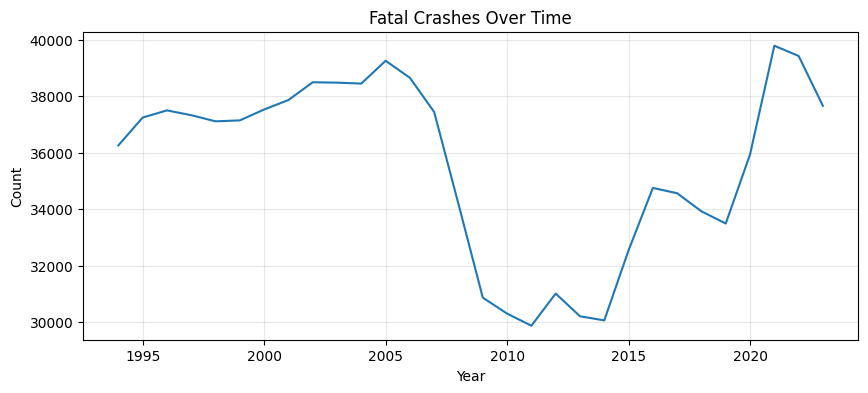

In [15]:
plot_df = df_long[df_long["colname"] == "Fatal Crashes"].sort_values("year")

plt.figure(figsize=(10,4))
plt.plot(plot_df["year"], plot_df["value"])
plt.title("Fatal Crashes Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


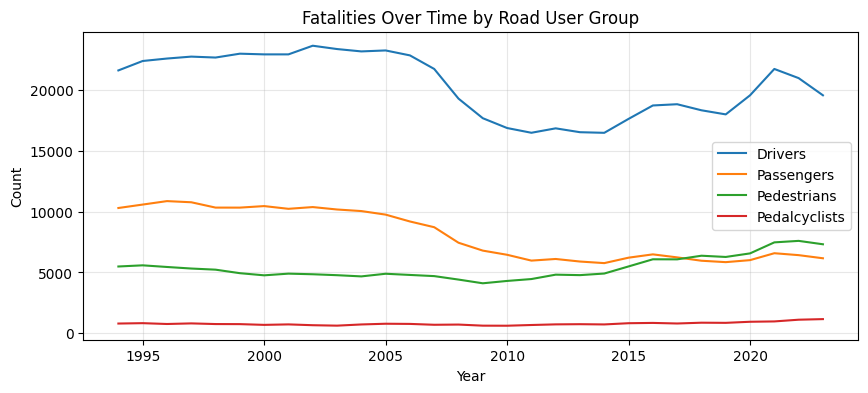

In [16]:
cats = ["Drivers", "Passengers", "Pedestrians", "Pedalcyclists"]

multi = df_long[df_long["colname"].isin(cats)].sort_values(["colname","year"])

plt.figure(figsize=(10,4))
for c in cats:
    tmp = multi[multi["colname"] == c]
    plt.plot(tmp["year"], tmp["value"], label=c)

plt.title("Fatalities Over Time by Road User Group")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


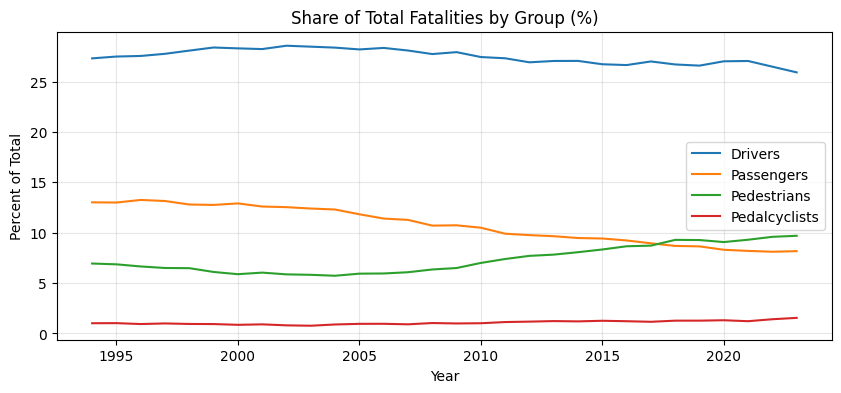

In [17]:
total = df_long[df_long["colname"].str.contains("Total", na=False)].groupby("year")["value"].sum()

share = df_long[df_long["colname"].isin(cats)].copy()
share["total"] = share["year"].map(total)
share["pct"] = 100 * share["value"] / share["total"]

plt.figure(figsize=(10,4))
for c in cats:
    tmp = share[share["colname"] == c].sort_values("year")
    plt.plot(tmp["year"], tmp["pct"], label=c)

plt.title("Share of Total Fatalities by Group (%)")
plt.xlabel("Year")
plt.ylabel("Percent of Total")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

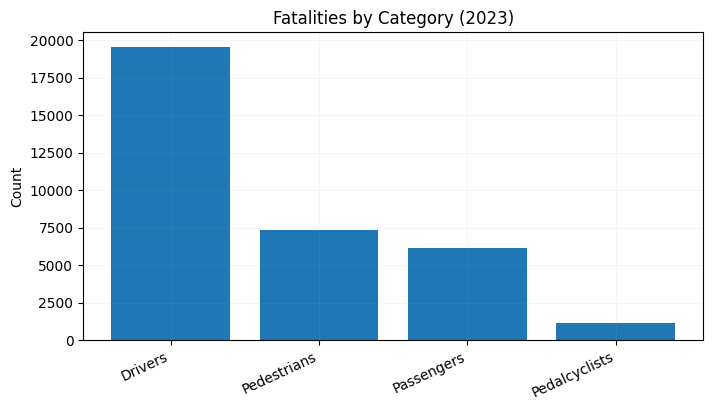

In [18]:
year = 2023
bar_df = df_clean[df_clean["colname"].isin(cats)][["colname", str(year)]].copy()
bar_df = bar_df.sort_values(str(year), ascending=False)

plt.figure(figsize=(8,4))
plt.bar(bar_df["colname"], bar_df[str(year)])
plt.title(f"Fatalities by Category ({year})")
plt.ylabel("Count")
plt.grid(True, alpha = 0.1)
plt.xticks(rotation=25, ha="right")
plt.show()


In [19]:
from sklearn.linear_model import LinearRegression

series = df_long[df_long["colname"] == "Fatal Crashes"].sort_values("year")

X = series[["year"]].values
y = series["value"].values

# train on all but last 5 years, test on last 5
split = -5
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = LinearRegression()
model.fit(X_train, y_train)

pred_test = model.predict(X_test)

# predict next 2 years
last_year = int(series["year"].max())
future_years = np.array([[last_year+1], [last_year+2]])
pred_future = model.predict(future_years)

pred_future

array([30001.60923077, 29710.76307692])

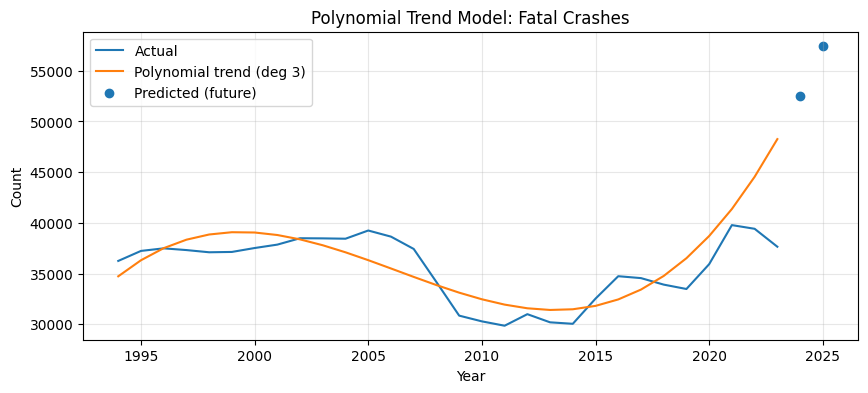

In [20]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
import numpy as np

model2 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
model2.fit(X_train, y_train)

pred_all2 = model2.predict(X)
pred_future2 = model2.predict(future_years)

plt.figure(figsize=(10,4))
plt.plot(series["year"], y, label="Actual")
plt.plot(series["year"], pred_all2, label="Polynomial trend (deg 3)")
plt.scatter(future_years.flatten(), pred_future2, label="Predicted (future)")
plt.title("Polynomial Trend Model: Fatal Crashes")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


I chose this visualization because it clearly highlights the overall downward and upward trends in fatalities over time without clutter. The clean line chart makes it easy to see turning points around 2008–2012 and the post-2020 increase.

Overall, fatal crashes declined significantly from the mid-2000s to early 2010s, but have risen again in recent years, suggesting renewed safety concerns.

In [21]:
# To use in Week 4 for EDA

df_clean.to_csv("nhtsa_clean.csv", index=False)
print("Saved: nhtsa_clean.csv")


Saved: nhtsa_clean.csv
